In [1]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np

In [2]:
sheet_id = "1VurJODWndk26VfyNd6IDgXsvX7uR1A_IxhTA4xcGRco"
sheet_gid = "0"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={sheet_gid}"
full_df = pd.read_csv(url)

In [3]:
df = full_df.copy()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
                           
now = datetime.now()
start_of_day = datetime(now.year, now.month, now.day)
start_of_month = datetime(now.year, now.month, 1)
start_of_week = now - timedelta(days=now.weekday())
current_quarter = (now.month - 1) // 3 + 1
start_of_quarter = datetime(now.year, 3 * (current_quarter - 1) + 1, 1)

df = df[df['Date'] < start_of_day]

df['Weight'] = df['Weight'].astype(str).str.replace(',', '.').str.strip()
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
df['Weight'] = df['Weight'].interpolate(method='linear')

df.tail()

,Date,Weight
1346,2025-08-12,72.1
1347,2025-08-13,72.1
1348,2025-08-14,72.1
1349,2025-08-15,72.1
1350,2025-08-16,71.6


In [4]:
weekly_df = df[df['Date'] < start_of_week].copy()
weekly_df = weekly_df.resample('W-MON', on='Date').mean().reset_index()

weekly_df.tail()

,Date,Weight
188,2025-07-14,73.885714
189,2025-07-21,73.457143
190,2025-07-28,72.657143
191,2025-08-04,72.271429
192,2025-08-11,71.957143


In [6]:
print(weekly_df)

          Date     Weight
0   2021-12-06  70.600000
1   2021-12-13  70.942857
2   2021-12-20  70.671429
3   2021-12-27  71.314286
4   2022-01-03  71.842857
..         ...        ...
188 2025-07-14  73.885714
189 2025-07-21  73.457143
190 2025-07-28  72.657143
191 2025-08-04  72.271429
192 2025-08-11  71.957143

[193 rows x 2 columns]


In [14]:
# Kopia ramki, żeby nie modyfikować oryginału
wd = weekly_df.copy()

birthdate = pd.to_datetime("1987-03-30")

wd["age"] = (wd["Date"] - birthdate).dt.days / 365.25
wd["age_sq"] = wd["age"] ** 2

# Cechy czasowe
wd["year"] = wd["Date"].dt.year
wd["month"] = wd["Date"].dt.month
wd["weekofyear"] = wd["Date"].dt.isocalendar().week.astype(int)
wd["dayofyear"] = wd["Date"].dt.dayofyear

# Trend (indeks czasu)
wd["t"] = np.arange(len(wd))

# Cechy sezonowe (cykliczne)
wd["month_sin"] = np.sin(2 * np.pi * wd["month"] / 12)
wd["month_cos"] = np.cos(2 * np.pi * wd["month"] / 12)

# Cechy opóźnione (lags)
for lag in [1, 2, 4]:
    wd[f"Weight_lag{lag}"] = wd["Weight"].shift(lag)

# Średnie ruchome (rolling means)
for window in [3, 6, 12]:
    wd[f"Weight_roll_mean{window}"] = wd["Weight"].shift(1).rolling(window).mean()

# Usunięcie NaN powstałych przez lag/rolling
wd = wd.dropna().reset_index(drop=True)


In [15]:
wd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                181 non-null    datetime64[ns]
 1   Weight              181 non-null    float64       
 2   age                 181 non-null    float64       
 3   age_sq              181 non-null    float64       
 4   year                181 non-null    int32         
 5   month               181 non-null    int32         
 6   weekofyear          181 non-null    int64         
 7   dayofyear           181 non-null    int32         
 8   t                   181 non-null    int64         
 9   month_sin           181 non-null    float64       
 10  month_cos           181 non-null    float64       
 11  Weight_lag1         181 non-null    float64       
 12  Weight_lag2         181 non-null    float64       
 13  Weight_lag4         181 non-null    float64       

In [16]:
wd

,Date,Weight,age,age_sq,year,month,weekofyear,dayofyear,t,month_sin,month_cos,Weight_lag1,Weight_lag2,Weight_lag4,Weight_roll_mean3,Weight_roll_mean6,Weight_roll_mean12
0,2022-02-28,71.771429,34.918549,1219.305060,2022,2,9,59,12,0.866025,5.000000e-01,71.471429,71.728571,71.714286,71.533333,71.630952,71.392857
1,2022-03-07,71.600000,34.937714,1220.643852,2022,3,10,66,13,1.000000,6.123234e-17,71.771429,71.471429,71.400000,71.657143,71.614286,71.490476
2,2022-03-14,71.257143,34.956879,1221.983379,2022,3,11,73,14,1.000000,6.123234e-17,71.600000,71.771429,71.728571,71.614286,71.614286,71.545238
3,2022-03-21,71.985714,34.976044,1223.323640,2022,3,12,80,15,1.000000,6.123234e-17,71.257143,71.600000,71.471429,71.542857,71.538095,71.594048
4,2022-03-28,71.600000,34.995209,1224.664636,2022,3,13,87,16,1.000000,6.123234e-17,71.985714,71.257143,71.771429,71.614286,71.635714,71.650000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,2025-07-14,73.885714,38.291581,1466.245184,2025,7,29,195,188,-0.500000,-8.660254e-01,73.514286,73.457143,73.614286,73.542857,73.676190,73.635714
177,2025-07-21,73.457143,38.310746,1467.713264,2025,7,30,202,189,-0.500000,-8.660254e-01,73.885714,73.514286,73.657143,73.619048,73.685714,73.695238
178,2025-07-28,72.657143,38.329911,1469.182079,2025,7,31,209,190,-0.500000,-8.660254e-01,73.457143,73.885714,73.457143,73.619048,73.597619,73.700000
179,2025-08-04,72.271429,38.349076,1470.651628,2025,8,32,216,191,-0.866025,-5.000000e-01,72.657143,73.457143,73.514286,73.333333,73.438095,73.605952


In [18]:
import datetime

# Zakresy dat
start_train = datetime.datetime(2021, 12, 6)   # początek Twoich danych
end_train   = datetime.datetime(2024, 12, 31)  # granica train/test

start_test  = datetime.datetime(2025, 1, 1)
end_test    = wd["Date"].max()  # do końca zbioru

# Podział na train/test
data_train = wd[(wd["Date"] >= start_train) & (wd["Date"] <= end_train)]
data_test  = wd[(wd["Date"] >= start_test)  & (wd["Date"] <= end_test)]

# Definicja cech i targetu
X_columns = [c for c in wd.columns if c not in ["Date", "Weight"]]
y_column = "Weight"

# Train set
X_train = data_train[X_columns]
y_train = data_train[y_column]

# Test set
X_test = data_test[X_columns]
y_test = data_test[y_column]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(149, 15) (149,)
(32, 15) (32,)


In [19]:
X_train

,age,age_sq,year,month,weekofyear,dayofyear,t,month_sin,month_cos,Weight_lag1,Weight_lag2,Weight_lag4,Weight_roll_mean3,Weight_roll_mean6,Weight_roll_mean12
0,34.918549,1219.305060,2022,2,9,59,12,8.660254e-01,5.000000e-01,71.471429,71.728571,71.714286,71.533333,71.630952,71.392857
1,34.937714,1220.643852,2022,3,10,66,13,1.000000e+00,6.123234e-17,71.771429,71.471429,71.400000,71.657143,71.614286,71.490476
2,34.956879,1221.983379,2022,3,11,73,14,1.000000e+00,6.123234e-17,71.600000,71.771429,71.728571,71.614286,71.614286,71.545238
3,34.976044,1223.323640,2022,3,12,80,15,1.000000e+00,6.123234e-17,71.257143,71.600000,71.471429,71.542857,71.538095,71.594048
4,34.995209,1224.664636,2022,3,13,87,16,1.000000e+00,6.123234e-17,71.985714,71.257143,71.771429,71.614286,71.635714,71.650000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,37.678303,1419.654482,2024,12,49,337,156,-2.449294e-16,1.000000e+00,72.200000,72.757143,73.100000,72.514286,72.861905,72.933929
145,37.697467,1421.099055,2024,12,50,344,157,-2.449294e-16,1.000000e+00,72.385714,72.200000,72.585714,72.447619,72.735714,72.893452
146,37.716632,1422.544363,2024,12,51,351,158,-2.449294e-16,1.000000e+00,72.814286,72.385714,72.757143,72.466667,72.640476,72.855357
147,37.735797,1423.990405,2024,12,52,358,159,-2.449294e-16,1.000000e+00,72.957143,72.814286,72.200000,72.719048,72.616667,72.860714


In [20]:
X_train.dtypes

age                   float64
age_sq                float64
year                    int32
month                   int32
weekofyear              int64
dayofyear               int32
t                       int64
month_sin             float64
month_cos             float64
Weight_lag1           float64
Weight_lag2           float64
Weight_lag4           float64
Weight_roll_mean3     float64
Weight_roll_mean6     float64
Weight_roll_mean12    float64
dtype: object

In [21]:
from sklearn.preprocessing import StandardScaler

# lista cech, które chcemy użyć w modelu
feature_columns = [
    't',
    'month_sin', 'month_cos',
    'Weight_lag1', 'Weight_lag2', 'Weight_lag4',
    'Weight_roll_mean3', 'Weight_roll_mean6', 'Weight_roll_mean12'
]

# jeśli dodasz wiek
# feature_columns += ['age', 'age_squared']

# przygotowanie scaler'a
scaler = StandardScaler()
scaler.fit(wd[feature_columns].iloc[:149])  # train set: pierwsze 149 wierszy

# kopiowanie danych, żeby zachować oryginały
X_train_scaled = wd[feature_columns].iloc[:149].copy()
X_test_scaled  = wd[feature_columns].iloc[149:].copy()

# skalowanie
X_train_scaled[feature_columns] = scaler.transform(X_train_scaled[feature_columns])
X_test_scaled[feature_columns]  = scaler.transform(X_test_scaled[feature_columns])

# y
y_train = wd['Weight'].iloc[:149].copy()
y_test  = wd['Weight'].iloc[149:].copy()

# sprawdzenie shapes
print(X_train_scaled.shape, y_train.shape)
print(X_test_scaled.shape, y_test.shape)


(149, 9) (149,)
(32, 9) (32,)


In [22]:
X_train_scaled

,t,month_sin,month_cos,Weight_lag1,Weight_lag2,Weight_lag4,Weight_roll_mean3,Weight_roll_mean6,Weight_roll_mean12
0,-1.720465,1.289325,0.761006,-0.156291,0.117759,0.122804,-0.085673,0.031001,-0.223156
1,-1.697216,1.479457,0.054053,0.147174,-0.145761,-0.203016,0.045382,0.012567,-0.104966
2,-1.673966,1.479457,0.054053,-0.026234,0.161679,0.137614,0.000017,0.012567,-0.038665
3,-1.650716,1.479457,0.054053,-0.373051,-0.014001,-0.128966,-0.075591,-0.071706,0.020430
4,-1.627467,1.479457,0.054053,0.363935,-0.365362,0.182044,0.000017,0.036268,0.088173
...,...,...,...,...,...,...,...,...,...
144,1.627467,0.060292,1.467960,0.580695,1.171839,1.559373,0.952682,1.392530,1.642658
145,1.650716,0.060292,1.467960,0.768555,0.600879,1.026213,0.882114,1.252954,1.593652
146,1.673966,0.060292,1.467960,1.202076,0.791199,1.203933,0.902277,1.147613,1.547529
147,1.697216,0.060292,1.467960,1.346583,1.230400,0.626343,1.169426,1.121278,1.554015


In [23]:
y_train

0      71.771429
1      71.600000
2      71.257143
3      71.985714
4      71.600000
         ...    
144    72.385714
145    72.814286
146    72.957143
147    73.557143
148    73.957143
Name: Weight, Length: 149, dtype: float64

In [24]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "alpha": [3e-06, 1e-5, 3e-5],
    "eta0": [0.01, 0.03, 0.1]
}

lr = SGDRegressor(penalty='l2', max_iter=1000, random_state=42)
grid_search = GridSearchCV(lr, param_grid, cv=5, scoring='neg_mean_absolute_error')

grid_search.fit(X_train_scaled, y_train)

# najlepsze parametry
print(grid_search.best_params_)

# model z najlepszymi parametrami
lr_best = grid_search.best_estimator_

# predykcje na zbiorze testowym
predictions = lr_best.predict(X_test_scaled)


{'alpha': 3e-05, 'eta0': 0.1}


In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [27]:
print('MSE: {0:.3f}'.format(mean_squared_error(y_test, predictions)))
print('MAE: {0:.3f}'.format(mean_absolute_error(y_test, predictions)))
print('R^2: {0:.3f}'.format(r2_score(y_test, predictions)))

MSE: 0.139
MAE: 0.309
R^2: 0.320


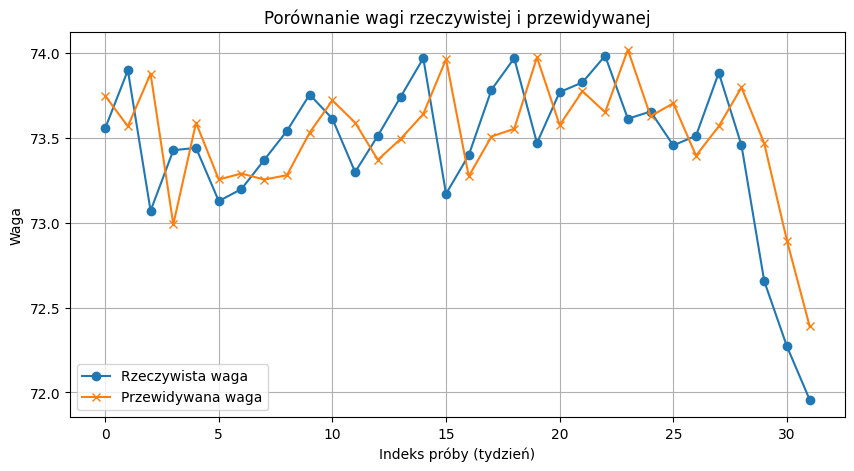

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Rzeczywista waga', marker='o')
plt.plot(predictions, label='Przewidywana waga', marker='x')
plt.title('Porównanie wagi rzeczywistej i przewidywanej')
plt.xlabel('Indeks próby (tydzień)')
plt.ylabel('Waga')
plt.legend()
plt.grid(True)
plt.show()


In [34]:
comparison_df = pd.DataFrame({
    'Date': wd['Date'].iloc[149:],  # daty odpowiadające zbiorowi testowemu
    'Weight_True': y_test.values,
    'Weight_Predicted': predictions
})
print(comparison_df.sample(10))

          Date  Weight_True  Weight_Predicted
152 2025-01-27    73.428571         72.991507
158 2025-03-10    73.757143         73.532863
177 2025-07-21    73.457143         73.798897
162 2025-04-07    73.742857         73.495265
159 2025-03-17    73.614286         73.722739
176 2025-07-14    73.885714         73.569969
171 2025-06-09    73.985714         73.652669
163 2025-04-14    73.971429         73.642348
178 2025-07-28    72.657143         73.469566
168 2025-05-19    73.471429         73.976269


In [37]:
#1 decimal only

from sklearn.preprocessing import StandardScaler

# lista cech, które chcemy użyć w modelu
feature_columns = [
    't',
    'month_sin', 'month_cos',
    'Weight_lag1', 'Weight_lag2', 'Weight_lag4',
    'Weight_roll_mean3', 'Weight_roll_mean6', 'Weight_roll_mean12'
]

# jeśli dodasz wiek
# feature_columns += ['age', 'age_squared']

# przygotowanie scaler'a
scaler = StandardScaler()
scaler.fit(wd[feature_columns].iloc[:149])  # train set: pierwsze 149 wierszy

# kopiowanie danych, żeby zachować oryginały
X_train_scaled = wd[feature_columns].iloc[:149].copy()
X_test_scaled  = wd[feature_columns].iloc[149:].copy()

# skalowanie
X_train_scaled[feature_columns] = scaler.transform(X_train_scaled[feature_columns])
X_test_scaled[feature_columns]  = scaler.transform(X_test_scaled[feature_columns])

# y

wd['Weight'] = wd['Weight'].round(1)

y_train = wd['Weight'].iloc[:149].copy()
y_test  = wd['Weight'].iloc[149:].copy()

# sprawdzenie shapes
print(X_train_scaled.shape, y_train.shape)
print(X_test_scaled.shape, y_test.shape)

(149, 9) (149,)
(32, 9) (32,)


In [39]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "alpha": [3e-06, 1e-5, 3e-5],
    "eta0": [0.01, 0.03, 0.1]
}

lr = SGDRegressor(penalty='l2', max_iter=1000, random_state=42)
grid_search = GridSearchCV(lr, param_grid, cv=5, scoring='neg_mean_absolute_error')

grid_search.fit(X_train_scaled, y_train)

# najlepsze parametry
print(grid_search.best_params_)

# model z najlepszymi parametrami
lr_best = grid_search.best_estimator_

# predykcje na zbiorze testowym
predictions = lr_best.predict(X_test_scaled)


{'alpha': 3e-05, 'eta0': 0.1}


In [40]:
print('MSE: {0:.3f}'.format(mean_squared_error(y_test, predictions)))
print('MAE: {0:.3f}'.format(mean_absolute_error(y_test, predictions)))
print('R^2: {0:.3f}'.format(r2_score(y_test, predictions)))

MSE: 0.141
MAE: 0.301
R^2: 0.297


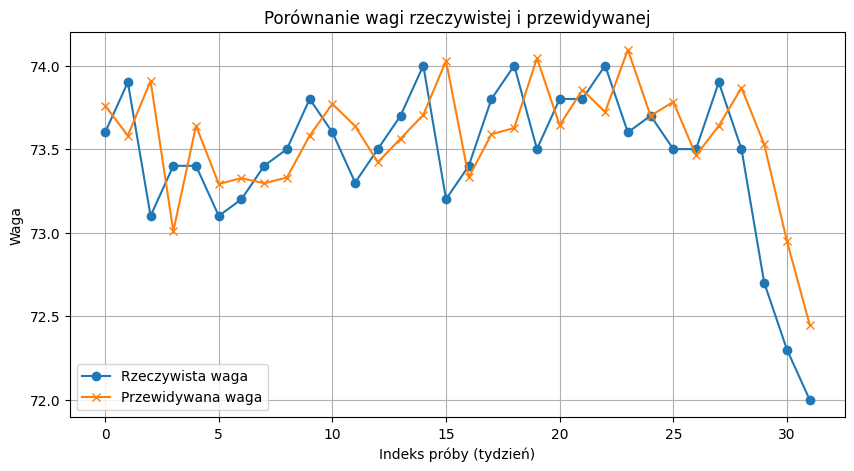

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Rzeczywista waga', marker='o')
plt.plot(predictions, label='Przewidywana waga', marker='x')
plt.title('Porównanie wagi rzeczywistej i przewidywanej')
plt.xlabel('Indeks próby (tydzień)')
plt.ylabel('Waga')
plt.legend()
plt.grid(True)
plt.show()


In [45]:
from sklearn.ensemble import RandomForestRegressor

param_grid = {"max_depth": [30, 50],
"min_samples_split": [3, 5, 10],
}
rf = RandomForestRegressor(n_estimators=1000)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_absolute_error')
grid_search.fit(X_train_scaled, y_train)

print(grid_search.best_params_)

rf_best = grid_search.best_estimator_
predictions = rf_best.predict(X_test_scaled)

{'max_depth': 50, 'min_samples_split': 10}


In [46]:
print('MSE: {0:.3f}'.format(mean_squared_error(y_test, predictions)))
print('MAE: {0:.3f}'.format(mean_absolute_error(y_test, predictions)))
print('R^2: {0:.3f}'.format(r2_score(y_test, predictions)))

MSE: 0.462
MAE: 0.617
R^2: -1.313


In [51]:
from sklearn.svm import SVR

param_grid = {"C": [1000, 3000, 10000],
              "epsilon": [0.00001, 0.00003, 0.0001]}
svr = SVR(kernel='linear')
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_absolute_error')
grid_search.fit(X_train_scaled, y_train)
print(grid_search.best_params_)

svr_best = grid_search.best_estimator_
predictions = svr_best.predict(X_test_scaled)

{'C': 10000, 'epsilon': 1e-05}


In [52]:
print('MSE: {0:.3f}'.format(mean_squared_error(y_test, predictions)))
print('MAE: {0:.3f}'.format(mean_absolute_error(y_test, predictions)))
print('R^2: {0:.3f}'.format(r2_score(y_test, predictions)))

MSE: 0.148
MAE: 0.291
R^2: 0.259
